In [41]:
# packages
import os
import joblib
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 
from sklearn.ensemble import GradientBoostingRegressor as GBR
from sklearn.model_selection import GridSearchCV

# set seed
seed = 5151

### You'll need the California housing data (CAhousing.csv) to complete this exercise. Your goal is to predict the median house value.

In [42]:
CAhousing = pd.read_csv('data/CAhousing.csv')
CAhousing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [43]:
CAhousing.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

In [44]:
CAhousing.shape

(20640, 10)

### There is a single categorical variable in this dataset that we will convert to a series of binary variables.

In [45]:
CAhousing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [46]:
# create binary variables for levels which have enough records, using '<1H OCEAN' as base.
CAhousing['ocean_prox_inland'] = (CAhousing.ocean_proximity == 'INLAND').astype(int)
CAhousing['ocean_prox_nearocean'] = (CAhousing.ocean_proximity == 'NEAR OCEAN').astype(int)
CAhousing['ocean_prox_nearbay'] = (CAhousing.ocean_proximity == 'NEAR BAY').astype(int)

# check for intended outcome
print(CAhousing['ocean_prox_inland'].value_counts())
print(CAhousing['ocean_prox_nearocean'].value_counts())
print(CAhousing['ocean_prox_nearbay'].value_counts())

ocean_prox_inland
0    14089
1     6551
Name: count, dtype: int64
ocean_prox_nearocean
0    17982
1     2658
Name: count, dtype: int64
ocean_prox_nearbay
0    18350
1     2290
Name: count, dtype: int64


In [47]:
indep_vars = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 
              'total_bedrooms', 'population', 'households', 'median_income', 
              'ocean_prox_inland', 'ocean_prox_nearocean', 'ocean_prox_nearbay']

X = CAhousing[indep_vars]
y = CAhousing['median_house_value']

In [48]:
X_train, X_test, y_train, y_test, Train, Test = train_test_split(X, y, CAhousing, 
                                                                 random_state = seed, 
                                                                 test_size = 0.33, 
                                                                 shuffle = True)

In [49]:
X_train.corr().style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_prox_inland,ocean_prox_nearocean,ocean_prox_nearbay
longitude,1.000000,-0.925043,-0.114497,0.047601,0.071954,0.097791,0.057057,-0.004860,-0.064518,0.044051,-0.472177
latitude,-0.925043,1.000000,0.013074,-0.037069,-0.068320,-0.106791,-0.071697,-0.087142,0.359341,-0.160357,0.355240
housing_median_age,-0.114497,0.013074,1.000000,-0.355823,-0.311887,-0.289245,-0.295687,-0.114457,-0.243520,0.018700,0.263273
total_rooms,0.047601,-0.037069,-0.355823,1.000000,0.929376,0.851145,0.916886,0.191664,0.032641,-0.003010,-0.034586
total_bedrooms,0.071954,-0.068320,-0.311887,0.929376,1.000000,0.872554,0.979795,-0.013910,-0.003210,0.005523,-0.030998
population,0.097791,-0.106791,-0.289245,0.851145,0.872554,1.000000,0.901979,-0.002895,-0.018429,-0.017394,-0.068435
households,0.057057,-0.071697,-0.295687,0.916886,0.979795,0.901979,1.000000,0.004934,-0.035431,0.007412,-0.021945
median_income,-0.004860,-0.087142,-0.114457,0.191664,-0.013910,-0.002895,0.004934,1.000000,-0.229922,0.027796,0.053362
ocean_prox_inland,-0.064518,0.359341,-0.243520,0.032641,-0.003210,-0.018429,-0.035431,-0.229922,1.000000,-0.260245,-0.238907
ocean_prox_nearocean,0.044051,-0.160357,0.018700,-0.003010,0.005523,-0.017394,0.007412,0.027796,-0.260245,1.000000,-0.133534


In [50]:
Train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_prox_inland,ocean_prox_nearocean,ocean_prox_nearbay
count,13828.000000,13828.000000,13828.000000,13828.000000,13683.000000,13828.000000,13828.000000,13828.000000,13828.000000,13828.000000,13828.000000,13828.000000
mean,-119.571769,35.635351,28.711383,2627.905265,536.854856,1425.571015,499.484741,3.868689,206872.486477,0.317689,0.126989,0.109199
std,1.995184,2.136714,12.576883,2156.762504,422.228349,1151.475717,384.310620,1.892871,115247.495307,0.465595,0.332972,0.311900
min,-124.350000,32.550000,1.000000,6.000000,1.000000,5.000000,1.000000,0.499900,14999.000000,0.000000,0.000000,0.000000
25%,-121.770000,33.940000,18.000000,1447.750000,296.000000,786.750000,281.000000,2.569850,119675.000000,0.000000,0.000000,0.000000
50%,-118.500000,34.250000,29.000000,2125.000000,434.000000,1165.000000,410.000000,3.525000,180000.000000,0.000000,0.000000,0.000000
75%,-118.020000,37.720000,37.000000,3137.000000,642.000000,1720.000000,601.000000,4.740050,264400.000000,1.000000,0.000000,0.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000,1.000000,1.000000


### We see that `total_bedrooms` has a few missing values, and it is also very correlated with `total_rooms`. Because of this, it's easiest to remove it from our training set.

In [51]:
indep_vars.remove("total_bedrooms")

### We'll define some helper functions here: 
(1) to calculate MSE, and 
(2) to display the improvement of a GBM on test data as additional trees are constructed.

In [52]:
def mse(y, y_hat):
    """
    Calculate the MSE of a model given actual and predicted values
    """
    # calculate the residual error for each individual record
    resid = y - y_hat
    # square the residual (hence "squared error")
    sq_resid = resid**2
    # calculate the sum of squared errors
    SSR = sum(sq_resid)
    # divide by the number of records to get the mean squared error
    MSE = SSR / y.shape[0]
    return MSE

def gbm_progress(model_name, X_test, y_test):
    """
    Plot the 'progress' of a GBM on a test set to assess robustness
    """
    test_error = np.zeros_like(model_name.train_score_)
    for idx, y_ in enumerate(model_name.staged_predict(X_test)):
        test_error[idx] = np.mean((y_test - y_)**2)

    plot_idx = np.arange(model_name.train_score_.shape[0])
    ax = subplots(figsize=(8,8))[1]
    ax.plot(plot_idx,
            model_name.train_score_,
            'b',
            label='Training')
    ax.plot(plot_idx,
            test_error,
            'r',
            label='Test')
    ax.legend();

### Build a basic GBM first.

In [53]:
# Documentation: https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html

gbm_basic = GBR(learning_rate=0.1,
               n_estimators=250,
               max_depth=10,
               min_samples_split=2,
               subsample=1,
               random_state=seed)

gbm_basic.fit(X_train[indep_vars], y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",250
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",10
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft c

In [54]:
y_hat_basic = gbm_basic.predict(X_test[indep_vars])

mse_basic = mse(y_test, y_hat_basic)
print('test mse: ',mse_basic)

test mse:  2267737061.189325


### When we plot the performance of the model on training and test data, we see that performance no longer improves after a certain number of trees (in this case, between 50-100 trees).

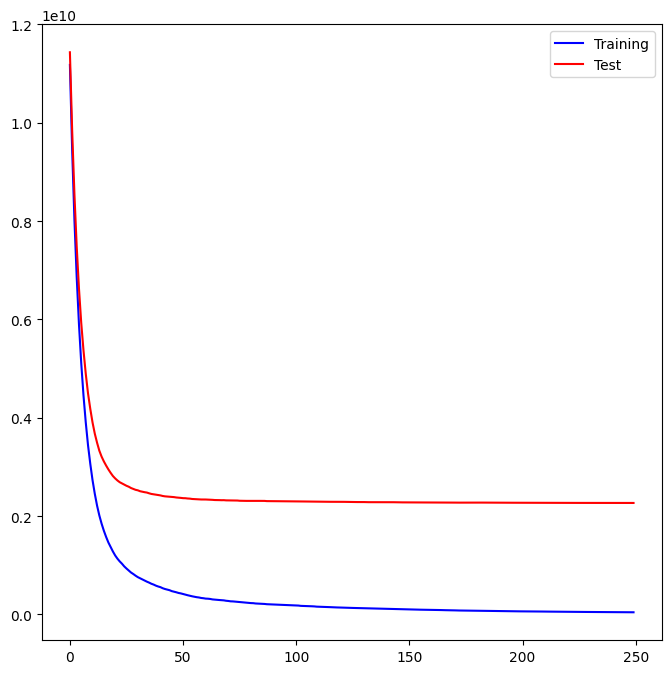

In [55]:
gbm_progress(gbm_basic, X_test[indep_vars], y_test)

### Now you'll have the chance to choose optimal hyperparameters to build a better GBM.
Once the candidate hyperparameters are chosen, use 5-fold cross-validation to decide which collection of hyperparameters are best.

In [56]:
def get_best_gbm(X, y, results_path="gridsearch_results.pkl", force_retrain=False):
    """
    Runs GridSearchCV OR loads precomputed results if available.

    Parameters:
        X, y : training data
        results_path : where results are saved
        force_retrain : if True, ignore saved file and rerun

    Returns:
        best_model : fitted model
        best_params : dict
    """

    # Fast Version: load existing results
    if os.path.exists(results_path) and not force_retrain:
        data = joblib.load(results_path)
        print("Loaded precomputed GridSearchCV results.")
        return data["best_model"], data["best_params"]

    # Slow Version: run grid search via cross-validation
    print("Running GridSearchCV...")

    ## Define model
    gbm_cv = GBR(random_state=seed)

    ## Define hyperparameter grid. Choose between 1 and 4 values to test for each one.
    #fillin
    param_grid = {
        "n_estimators": [500, 700],
        "learning_rate": [.01, .05],
        "max_depth": [3, 4],
        "min_samples_leaf": [20, 50],
        "subsample": [.8]
    }

    grid_search = GridSearchCV(
        estimator=gbm_cv,
        param_grid=param_grid,
        cv=5,                               # number of folds
        scoring="neg_mean_squared_error",   # how we evaluate which model is best
        n_jobs=-1,                          # use all available cores
        verbose=3
    )

    grid_search.fit(X, y)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    ## Save results. Gradescope will use this file instead of rerunning the grid search.
    joblib.dump({
        "best_model": best_model,
        "best_params": best_params,
        "cv_results": grid_search.cv_results_
    }, results_path)

    print(f"Saved results to {results_path}")

    return best_model, best_params

In [57]:
# Identify best model
best_model, best_params = get_best_gbm(X_train[indep_vars], y_train, force_retrain=False)

print("Best parameters:")
print(best_params)

Loaded precomputed GridSearchCV results.
Best parameters:
{'learning_rate': 0.1, 'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 250, 'subsample': 0.8}


### Your grade on this assignment will be partially determined by the mean squared error on a separate holdout set. You can approximate this using the test set.

In [58]:
# Evaluate on test set 
y_pred = best_model.predict(X_test[indep_vars])
mse_best = mse(y_test, y_pred)

print("Test MSE:", mse_best)

Test MSE: 2215612578.8679085
